In [30]:
# --- repo bootstrap: make `panelclv` importable and relative data paths resolve ---
import os, sys
from pathlib import Path
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)                                 # so "Datasets/..." resolve from repo root
_src = _root / 'src'
if _src.exists() and str(_src) not in sys.path:  # fallback if panelclv isn't pip-installed
    sys.path.insert(0, str(_src))
# ---------------------------------------------------------------------------------

%reload_ext autoreload
%autoreload 2
# ---------------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------------
import json
from pathlib import Path

# ---------------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.models import (
    MultinomialLSTMModel,  # softmax-over-counts LSTM (classifier head)
    compute_class_weights,  # class weights for weighted_ce / focal
    InferenceMultinomialLSTMModel,  # same backbone, sampling head
    mc_forecast,  # Valendin-style AR holdout rollout — LSTM (stateful)
    mc_forecast_transformer,  # same rollout for the Transformer (stateless / growing-window)
    compute_forecast_metrics,  # RMSE / bias% / aggregate-MAPE
)
from panelclv.training import (
    fit_model,  # shared training loop (CE / weighted_ce / focal / emd)
)
from panelclv.tuning import (
    run_optuna_study,  # hyper-parameter + covariate search
)
from panelclv.evaluation import (
    weekly_actuals,
    weekly_aggregate_predictions,
    plot_weekly_aggregated,
    metrics_table,
    alignment_check,
    save_predictions_to_csv,
)
from panelclv.experiments import (
    make_data_builder,  # builds the Optuna data_builder closure
    build_inference_from_trial,  # rebuilds the winning model + loads its checkpoint
    refit_best_trial,  # warm-start retrain the winner on the full calibration window
)
import numpy as np
import matplotlib.pyplot as plt
from panelclv.data_preparation import pareto_simulation as ps
# ---------------------------------------------------------------------------
# Reproducibility: seed the only unseeded randomness left in the pipeline —
# model weight init + DataLoader shuffle (CPU RNG) and dropout masks (GPU RNG).
# The Optuna TPE sampler and the MC/Pareto forecasts already take their own
# seeds, so these two lines make a full run (study -> forecast) reproducible.
# Set once here, before any model is built or trained.
# ---------------------------------------------------------------------------
GLOBAL_SEED = 42
torch.manual_seed(GLOBAL_SEED)          # CPU init + DataLoader shuffle order
torch.cuda.manual_seed_all(GLOBAL_SEED)  # dropout masks on GPU (ROCm)


## Dataset Generation

### Without sesonality

In [2]:
from panelclv.data_preparation import pareto_simulation as ps

# --- grid axes -------------------------------------------------------------------
r = 2.0
mean_transaction_rates = [0.01, 0.05, 0.10]#, 0.20, 0.40, 0.60


s = 2.0
churn_rates = [0.20, 0.40, 0.60, 0.80]


                                                                       # 4 betas
# grid = 6 x 4 = 24 (alpha, beta) combinations

N_CUSTOMERS = 1000
N_WEEKS = 156
N_DATASETS =10
OUT_PATH ="Datasets/Synthetic"

study_dir, manifest = ps.generate_pnbd_study(
    mean_transaction_rates, churn_rates,
    n_customers=N_CUSTOMERS,
    n_weeks=N_WEEKS,
    n_datasets=N_DATASETS,
    out_path=OUT_PATH,
    r=r, s=s,
    # study_name="my_study",   # optional; auto-timestamped if omitted
    base_seed=42,
)

print("study saved to:", study_dir)
print("datasets generated:", len(manifest))   # 24 combos x 5 = 120
manifest.head()




KeyboardInterrupt: 

### With Sesonality

In [14]:
from panelclv.data_preparation import pareto_simulation as ps

# --- grid axes -------------------------------------------------------------------
r = 2.0
s = 2.0
mean_transaction_rates = [0.01, 0.05, 0.10, 0.30]        # -> alpha = r / rate
churn_rates            = [0.20, 0.40, 0.60, 0.80]  # -> beta  (dropout by horizon)
n_weeks_for_churn_rate = 52

# --- seasonality (fixed for the whole study) -------------------------------------
# High-season weeks-of-year that recur every year (calibration + holdout).
# e.g. week 12 (spring), 25 (summer), 47 (year-end holiday).
seasonal_peaks     = [12, 25,30, 47]
seasonal_amplitude = 1.5      # relative peak strength (0 = off)
seasonal_width     = 3     # weeks each peak spans (0 = single-week spike)

# --- what to generate ------------------------------------------------------------
N_CUSTOMERS = 1000
N_WEEKS     = 156
N_DATASETS  = 10
OUT_PATH    = "Datasets/Synthetic"

study_dir, manifest = ps.generate_pnbd_study(
    mean_transaction_rates, churn_rates,
    n_customers=N_CUSTOMERS,
    n_weeks=N_WEEKS,
    n_datasets=N_DATASETS,
    out_path=OUT_PATH,
    r=r, s=s,
    n_weeks_for_churn_rate=n_weeks_for_churn_rate,
    seasonal_peaks=seasonal_peaks,          # <-- seasonality
    seasonal_amplitude=seasonal_amplitude,
    seasonal_width=seasonal_width,
    base_seed=42,
    # study_name="my_seasonal_study",       # optional; auto-timestamped if omitted
)

print("study saved to:", study_dir)
print("datasets generated:", len(manifest))   # 4 x 4 combos x 10 = 160
manifest.head()

study saved to: Datasets/Synthetic/pnbd_study_4x4x10_20260716-154143
datasets generated: 160


,combo,dataset,replicate,mean_transaction_rate,churn_rate,alpha,beta,r,s,n_customers,n_weeks,seed,panel_path
0,Dataset_1_20,Dataset_1,1,0.01,0.2,200.0,440.55107,2.0,2.0,1000,156,42,Datasets/Synthetic/pnbd_study_4x4x10_20260716-...
1,Dataset_1_20,Dataset_2,2,0.01,0.2,200.0,440.55107,2.0,2.0,1000,156,43,Datasets/Synthetic/pnbd_study_4x4x10_20260716-...
2,Dataset_1_20,Dataset_3,3,0.01,0.2,200.0,440.55107,2.0,2.0,1000,156,44,Datasets/Synthetic/pnbd_study_4x4x10_20260716-...
3,Dataset_1_20,Dataset_4,4,0.01,0.2,200.0,440.55107,2.0,2.0,1000,156,45,Datasets/Synthetic/pnbd_study_4x4x10_20260716-...
4,Dataset_1_20,Dataset_5,5,0.01,0.2,200.0,440.55107,2.0,2.0,1000,156,46,Datasets/Synthetic/pnbd_study_4x4x10_20260716-...


## Reuse Datasets

In [3]:
#To pull any dataset back for training later:
# study_dir is the path printed above (or point at the folder directly)
study_dir = "/home/virthian/Desktop/Thesis/panelclv/Datasets/Synthetic/pnbd_study_4x4x10_20260716-153349"
ps.list_pnbd_datasets(study_dir)               # manifest of all 120, rebuilt from disk

panel, ground_truth, config = ps.load_pnbd_dataset(study_dir, "Dataset_1_20", "Dataset_1")
# panel -> PanelConfig(frequency="weekly", time_cols=("year","week"),
#                      target_col="Transactions") -> prepare_dataset

## Check dataset

never-buyers (0 tx all-window): 465 / 1000 -- dropped later by require_calibration_activity
customers x weeks   : 1000 x 156  (156,000 rows)
params (r,a,s,b)    : (2.0, 200.0, 2.0, 440.55106965997794)
zero-count rows     : 99.3%   (Pareto/NBD panels are sparse)
txns/customer       : mean 1.12, median 1, max 10
weekly rate r/alpha : 0.0100 (while alive)  vs  panel mean 0.0072 (incl. dead weeks)
still-alive at end  : 52.0%   (from ground-truth tau)


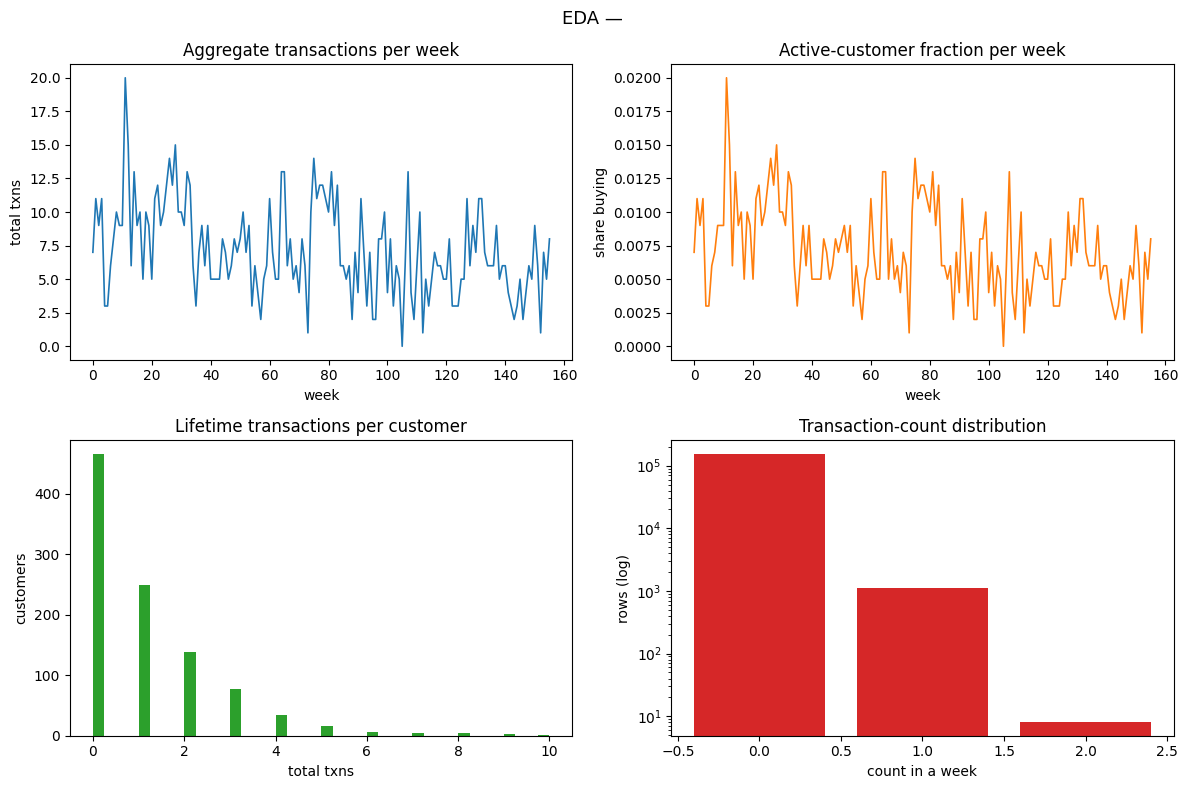

In [4]:
# --- EDA / sanity-check for a generated Pareto/NBD panel -------------------------


WEEKS_PER_YEAR = ps.WEEKS_PER_YEAR
N   = config["n_customers"]
W   = config["n_weeks"]
r, alpha, s, beta = (config["params"][k] for k in ("r", "alpha", "s", "beta"))

# A global week ordinal 0..W-1 from (year, week), so we can look at time as one axis.
panel = panel.copy()
panel["t"] = (panel["year"] - panel["year"].min()) * WEEKS_PER_YEAR + panel["week"]

# --- 1. Integrity invariants (fail loudly if the schema is wrong) ----------------
assert list(panel.columns[:4]) == ["Id", "year", "week", "Transactions"], "unexpected columns"
assert not panel[["Id", "year", "week", "Transactions"]].isna().any().any(), "NaNs present"
assert len(panel) == N * W, f"expected {N*W} rows, got {len(panel)}"                # rectangular
assert panel.groupby("Id")["t"].size().eq(W).all(), "not every customer has all weeks"
assert (panel["Transactions"] >= 0).all(), "negative counts"
# NOTE: with birth_purchase=False there is NO guaranteed week-0 entry — customers
# emerge as they first buy, and some never buy. Report those instead of asserting:
never_buyers = int((panel.groupby("Id")["Transactions"].sum() == 0).sum())
print(f"never-buyers (0 tx all-window): {never_buyers} / {panel['Id'].nunique()} "
      f"-- dropped later by require_calibration_activity")

# --- 2. Textual summary ----------------------------------------------------------
totals   = panel.groupby("Id")["Transactions"].sum()          # lifetime purchases per customer
zero_frac = (panel["Transactions"] == 0).mean()               # sparsity of the panel
# Empirical vs theoretical purchase rate. r/alpha is the rate *while alive*; the
# panel-wide mean is lower because dead weeks (all zeros) drag it down.

print(f"customers x weeks   : {N} x {W}  ({len(panel):,} rows)")
print(f"params (r,a,s,b)    : ({r}, {alpha}, {s}, {beta})")
print(f"zero-count rows     : {zero_frac:.1%}   (Pareto/NBD panels are sparse)")
print(f"txns/customer       : mean {totals.mean():.2f}, median {totals.median():.0f}, max {totals.max()}")
print(f"weekly rate r/alpha : {r/alpha:.4f} (while alive)  vs  panel mean {panel['Transactions'].mean():.4f} (incl. dead weeks)")
if ground_truth is not None:                                  # cross-check vs the latent truth
				alive_end = (ground_truth["tau"] >= W).mean()
				print(f"still-alive at end  : {alive_end:.1%}   (from ground-truth tau)")

# --- 3. Diagnostic plots ---------------------------------------------------------
weekly_total  = panel.groupby("t")["Transactions"].sum()                       # aggregate demand
active_frac   = panel.assign(active=panel["Transactions"] > 0) \
																					.groupby("t")["active"].mean()                            # buyers per week
count_dist    = panel["Transactions"].value_counts().sort_index()             # 0,1,2,... frequencies


fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"EDA — ", fontsize=13)

# (a) THE Pareto/NBD signature: total weekly purchasing decays as the cohort dies off.
ax[0, 0].plot(weekly_total.index, weekly_total.values, lw=1.2)
ax[0, 0].set(title="Aggregate transactions per week", xlabel="week", ylabel="total txns")

# (b) Same story from the survival side: fraction of customers buying each week.
ax[0, 1].plot(active_frac.index, active_frac.values, lw=1.2, color="C1")
ax[0, 1].set(title="Active-customer fraction per week", xlabel="week", ylabel="share buying")

# (c) Heterogeneity: the Gamma(r, alpha) rate spread shows up as a skewed
#     per-customer lifetime-purchase distribution (many light, few heavy buyers).
ax[1, 0].hist(totals.values, bins=40, color="C2")
ax[1, 0].set(title="Lifetime transactions per customer", xlabel="total txns", ylabel="customers")

# (d) Count sparsity: mass piled on 0/1, thin tail — a healthy count panel.
ax[1, 1].bar(count_dist.index, count_dist.values, color="C3")
ax[1, 1].set(title="Transaction-count distribution", xlabel="count in a week", ylabel="rows (log)")
ax[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()



What to look for when you run it:
- The assertions pass — schema, rectangular N×W shape, every customer present in every week, week-0 cohort entry for all, no NaNs/negatives.
- Top-left decays — this is the defining Pareto/NBD signature. The cohort is born at week 0 with no new acquisition, so as customers churn, total weekly demand slides downward. A flat line would mean churn isn't biting (check s/β); a cliff means everyone dies fast.
- Top-right decays too — the survival view of the same thing.
- Bottom-left is right-skewed — the Gamma(r, α) rate heterogeneity: a long tail of heavy buyers over a bulk of light ones.
- Bottom-right piles on 0 and 1 — weekly counts are sparse, as expected for low weekly rates.

In [ ]:
# --- Train one Optuna-tuned model per generated dataset --------------------------
import torch
from pathlib import Path
from panelclv.configs.panel_config import PanelConfig
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.data_preparation import pareto_simulation as ps
from panelclv.studies import run_study_suite, StudySuiteConfig, ModelSpec

device = "cuda" if torch.cuda.is_available() else "cpu"

# PanelConfig matching the SYNTHETIC panels: weekly, start_year=1999, N_WEEKS=156
# => 2y calibration (1999-2000) + 1y holdout (2001), no covariates.
# NOTE: if you change N_WEEKS or start_year in generation, update these windows.
synth_cfg = PanelConfig(
    id_col="Id", target_col="Transactions", frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    validation_start="2000-01-01",                      # last cal. year = temporal val split
    holdout_start="2001-01-01", holdout_end="2001-12-31",
    time_cols=("year", "week"), clip_target_upper=6,
    require_calibration_activity=True,
				
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    known_future=(), static=(), observed_past=(),       # pure Pareto/NBD data: no covariates
    embedded_cols={"Transactions": "auto"},
)

# The single model type, Optuna-tuned. n_studies_per_model=1 (below) => exactly
# ONE model of this type per dataset — no replicate models.
lstm_spec = ModelSpec(
    name="LSTM", model_type="lstm",
    n_trials=20,                                         # Optuna trials per dataset
    data_info={
        "n_epochs": 100, "patience": 7,
        "batch_size":       {64, 128, 256},
        "learning_rate":    (1e-4, 1e-2, "log"),
        "embedding_dim":    {64, 128, 256},
        "lstm_hidden_size": {32, 64, 128},
        "dense_units":      {32, 64, 128},
        "dropout":          {0.0, 0.2, 0.4},
        "loss_type": "cross_entropy",
        "verbose": False,
    },
)

pareto_spec = ModelSpec(name="ParetoNBD", model_type="pareto_nbd")

# Results mirror the dataset study: Studies/<generation-study>/<combo>__<dataset>/
TRAIN_BASE = Path("Studies") / study_dir.name
TRAIN_BASE.mkdir(parents=True, exist_ok=True)           # studies_base_path must exist

datasets = ps.list_pnbd_datasets(study_dir)             # every dataset in the study
trained = {}
for row in datasets.itertuples(index=False):
    panel, ground_truth, ds_cfg = ps.load_pnbd_dataset(study_dir, row.combo, row.dataset)
    data_full = dynamic_panel_dataset.prepare_dataset(panel, synth_cfg)

    suite_cfg = StudySuiteConfig(
        studies_base_path=TRAIN_BASE,
        study_name=f"{row.combo}__{row.dataset}",       # one suite folder per dataset
        data=data_full,
        models=[lstm_spec, pareto_spec],
        n_studies_per_model=1,                          # <-- ONE model per dataset
        prediction_source="refit",                      # paper's final full-calibration retrain
        n_simulations=200,
        base_seed=42,
        device=device,
        keep_only_best_checkpoint=True,                 # over 100+ runs, saves a lot of disk
        overwrite=True,                                 # safe to re-run a dataset
    )
    root = run_study_suite(suite_cfg)
    trained[(row.combo, row.dataset)] = root
    print("trained:", row.combo, row.dataset, "->", root)

print(f"\nDone: {len(trained)} models under {TRAIN_BASE}")

[I 2026-07-15 20:24:02,134] A new study created in memory with name: study_01


N=969 T_CAL=104 T_HOLD=52 F=3
validation_start=2000-01-01 -> val_start_idx=52 (train periods 0..51, validation periods 52..103, V=52)
seq_cols   = ['Transactions', 'week_sin', 'week_cos']
target_col = 'Transactions' at index 0
calibration (969, 104, 3) | samples (969, 103, 3) | targets (969, 103, 1) | holdout (969, 52, 3)
embedded_cols = {'Transactions': 7}


[I 2026-07-15 20:24:25,526] Trial 0 finished with value: 0.3212312385439873 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 128, 'dense_units': 32, 'dropout': 0.4, 'learning_rate': 0.00032273216524928187, 'weight_decay': 1.688650397596816e-06, 'batch_size': 64}. Best is trial 0 with value: 0.3212312385439873.
[I 2026-07-15 20:24:36,929] Trial 1 finished with value: 0.3205062076449394 and parameters: {'embedding_dim': 256, 'lstm_hidden_size': 64, 'dense_units': 32, 'dropout': 0.2, 'learning_rate': 0.0003346644990598678, 'weight_decay': 1.0483787180852643e-06, 'batch_size': 256}. Best is trial 1 with value: 0.3205062076449394.
[I 2026-07-15 20:24:43,295] Trial 2 finished with value: 0.3178717792034149 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 32, 'dense_units': 32, 'dropout': 0.0, 'learning_rate': 0.006215764324314727, 'weight_decay': 6.723036752122272e-06, 'batch_size': 128}. Best is trial 2 with value: 0.3178717792034149.
[I 2026-07-15 20:24:55,060] Trial 3 f

[refit] Epoch   1/5 | train_loss=0.3249 train_acc=0.9066
[refit] Epoch   2/5 | train_loss=0.3242 train_acc=0.9066
[refit] Epoch   3/5 | train_loss=0.3248 train_acc=0.9066
[refit] Epoch   4/5 | train_loss=0.3233 train_acc=0.9066
[refit] Epoch   5/5 | train_loss=0.3239 train_acc=0.9066


[I 2026-07-15 20:26:12,776] A new study created in memory with name: study_01


...

[refit] Epoch   1/5 | train_loss=0.1937 train_acc=0.9543
[refit] Epoch   2/5 | train_loss=0.1924 train_acc=0.9543
[refit] Epoch   3/5 | train_loss=0.1908 train_acc=0.9543
[refit] Epoch   4/5 | train_loss=0.1934 train_acc=0.9543
[refit] Epoch   5/5 | train_loss=0.1949 train_acc=0.9543


[I 2026-07-16 00:14:10,118] A new study created in memory with name: study_01


trained: Dataset_5_80 Dataset_8 -> Studies/pnbd_study_3x4x10_20260715-202011/Dataset_5_80__Dataset_8
N=837 T_CAL=104 T_HOLD=52 F=3
validation_start=2000-01-01 -> val_start_idx=52 (train periods 0..51, validation periods 52..103, V=52)
seq_cols   = ['Transactions', 'week_sin', 'week_cos']
target_col = 'Transactions' at index 0
calibration (837, 104, 3) | samples (837, 103, 3) | targets (837, 103, 1) | holdout (837, 52, 3)
embedded_cols = {'Transactions': 7}


[I 2026-07-16 00:14:18,575] Trial 0 finished with value: 0.18865129351615906 and parameters: {'embedding_dim': 128, 'lstm_hidden_size': 128, 'dense_units': 32, 'dropout': 0.4, 'learning_rate': 0.00032273216524928187, 'weight_decay': 1.688650397596816e-06, 'batch_size': 64}. Best is trial 0 with value: 0.18865129351615906.
[I 2026-07-16 00:14:25,761] Trial 1 finished with value: 0.18685990944504738 and parameters: {'embedding_dim': 256, 'lstm_hidden_size': 64, 'dense_units': 32, 'dropout': 0.2, 'learning_rate': 0.0003346644990598678, 'weight_decay': 1.0483787180852643e-06, 'batch_size': 256}. Best is trial 1 with value: 0.18685990944504738.
[I 2026-07-16 00:14:28,280] Trial 2 finished with value: 0.18511269986629486 and parameters: {'embedding_dim': 64, 'lstm_hidden_size': 32, 'dense_units': 32, 'dropout': 0.0, 'learning_rate': 0.006215764324314727, 'weight_decay': 6.723036752122272e-06, 'batch_size': 128}. Best is trial 2 with value: 0.18511269986629486.
[I 2026-07-16 00:14:36,682] Tri

[refit] Epoch   1/5 | train_loss=0.2025 train_acc=0.9525
[refit] Epoch   2/5 | train_loss=0.2010 train_acc=0.9525
[refit] Epoch   3/5 | train_loss=0.2003 train_acc=0.9525
[refit] Epoch   4/5 | train_loss=0.1986 train_acc=0.9525
[refit] Epoch   5/5 | train_loss=0.1981 train_acc=0.9525
trained: Dataset_5_80 Dataset_9 -> Studies/pnbd_study_3x4x10_20260715-202011/Dataset_5_80__Dataset_9

Done: 120 models under Studies/pnbd_study_3x4x10_20260715-202011


### Version 2 Test

In [ ]:
# --- Train one Optuna-tuned model per generated dataset --------------------------
import torch
from pathlib import Path
from tqdm.auto import tqdm
from panelclv.configs.panel_config import PanelConfig
from panelclv.data_preparation import dynamic_panel_dataset
from panelclv.data_preparation import pareto_simulation as ps
from panelclv.studies import run_study_suite, StudySuiteConfig, ModelSpec

device = "cuda" if torch.cuda.is_available() else "cpu"

# PanelConfig matching the SYNTHETIC panels: weekly, start_year=1999, N_WEEKS=156
# => 2y calibration (1999-2000) + 1y holdout (2001), no covariates.
# NOTE: if you change N_WEEKS or start_year in generation, update these windows.
synth_cfg = PanelConfig(
    id_col="Id", target_col="Transactions", frequency="weekly",
    training_start="1999-01-01", training_end="2000-12-31",
    validation_start="2000-01-01",                      # last cal. year = temporal val split
    holdout_start="2001-01-01", holdout_end="2001-12-31",
    time_cols=("year", "week"), clip_target_upper=6,
    require_calibration_activity=True,
    time_features={"add_year_idx": True, "add_week_sin_cos": True},
    known_future=(), static=(), observed_past=(),       # pure Pareto/NBD data: no covariates
    embedded_cols={"Transactions": "auto"},
)

# The single model type, Optuna-tuned. n_studies_per_model=1 (below) => exactly
# ONE model of this type per dataset — no replicate models.
lstm_spec = ModelSpec(
    name="LSTM", model_type="lstm",
    n_trials=20,                                         # Optuna trials per dataset
    data_info={
        "n_epochs": 100, "patience": 7,
        "batch_size":       {64, 128, 256},
        "learning_rate":    (1e-4, 1e-2, "log"),
        "embedding_dim":    {64, 128, 256},
        "lstm_hidden_size": {32, 64, 128},
        "dense_units":      {32, 64, 128},
        "dropout":          {0.0, 0.2, 0.4},
        "loss_type": "cross_entropy",
        "verbose": False,
    },
)

pareto_spec = ModelSpec(name="ParetoNBD", model_type="pareto_nbd")

# Results mirror the dataset study: Studies/<generation-study>/<combo>__<dataset>/
TRAIN_BASE = Path("Studies") / study_dir.name
TRAIN_BASE.mkdir(parents=True, exist_ok=True)           # studies_base_path must exist

datasets = ps.list_pnbd_datasets(study_dir)             # every dataset in the study
trained = {}

# Progress bar over datasets (the meaningful unit). set_postfix_str shows the
# dataset currently training; tqdm.write logs each completion without breaking the bar.
pbar = tqdm(datasets.itertuples(index=False), total=len(datasets),
            desc="Training per dataset", unit="dataset")
for row in pbar:
    pbar.set_postfix_str(f"{row.combo}/{row.dataset}")
    panel, ground_truth, ds_cfg = ps.load_pnbd_dataset(study_dir, row.combo, row.dataset)
    data_full = dynamic_panel_dataset.prepare_dataset(panel, synth_cfg)

    suite_cfg = StudySuiteConfig(
        studies_base_path=TRAIN_BASE,
        study_name=f"{row.combo}__{row.dataset}",       # one suite folder per dataset
        data=data_full,
        models=[lstm_spec, pareto_spec],
        n_studies_per_model=1,                          # <-- ONE model per dataset
        prediction_source="refit",                      # paper's final full-calibration retrain
        n_simulations=200,
        base_seed=42,
        device=device,
        keep_only_best_checkpoint=True,                 # over 100+ runs, saves a lot of disk
        overwrite=True,                                 # safe to re-run a dataset
    )
    root = run_study_suite(suite_cfg)
    trained[(row.combo, row.dataset)] = root
    tqdm.write(f"trained: {row.combo}/{row.dataset} -> {root}")

print(f"\nDone: {len(trained)} models under {TRAIN_BASE}")

### Study analysis

### Load Analysis

In [28]:
# study_dir = the GENERATION folder (synthetic panels + per-dataset config.json).
# collect_grid_results derives train_base = Studies/<study_dir name>, i.e. the
# trained-results folder you pulled from Drive. Both must share the same name.
study_dir = "/home/virthian/Desktop/Thesis/panelclv/Datasets/Synthetic/pnbd_study_4x4x10_20260716-154143"



### Analysis

**This cell needs a re-run grid.** `collect_grid_results` reads the `mape_aggregate` column, which is what `compute_forecast_metrics` returns today. The archived grid under `Studies/pnbd_study_4x4x10_.../` was written before that key lost its `_style` suffix, so its `results.csv` headers no longer match and `getattr` raises `AttributeError` on the first row.

Staying readable by older archives was dropped as a requirement when rollout-composite selection was deleted, so this is a known cost rather than a bug. Re-run the grid, or rename that one column header in each `results.csv`, before running the cell below. Asking only for the metrics a given archive does carry — `collect_grid_results(study_dir, metrics=("rmse", "bias_percent"))` — also works, at the price of the MAPE panels.


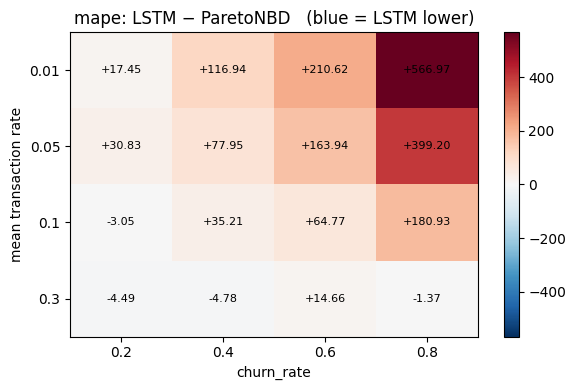

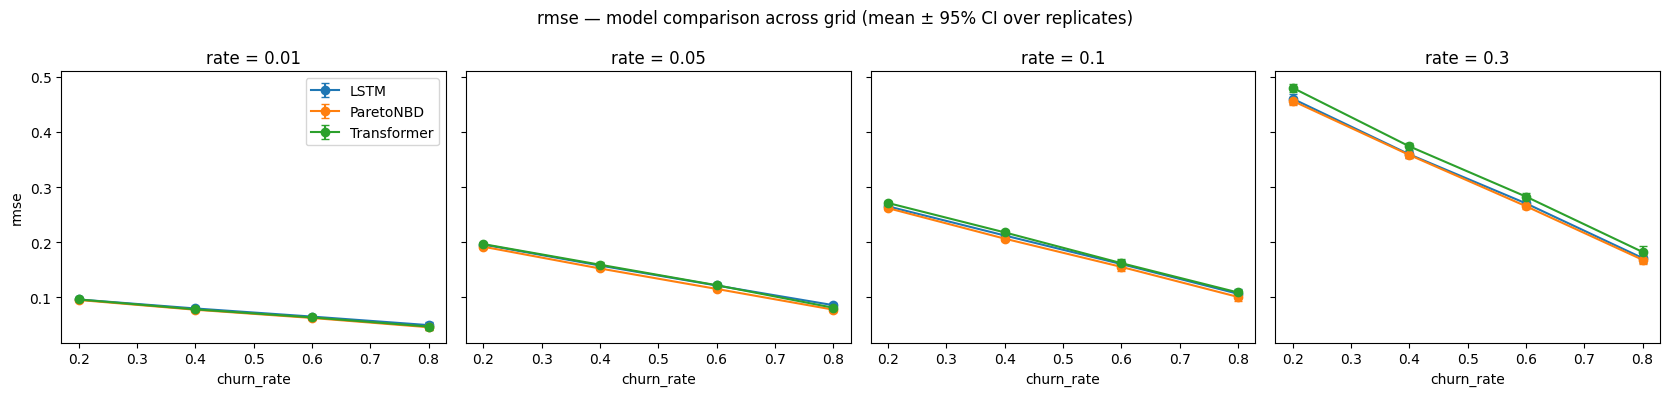

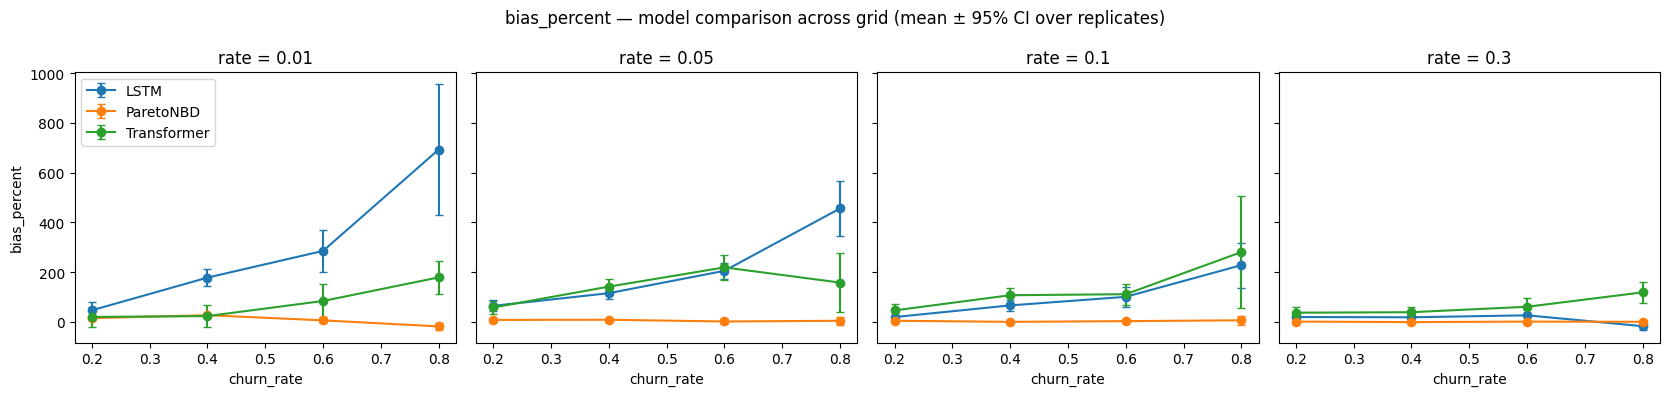

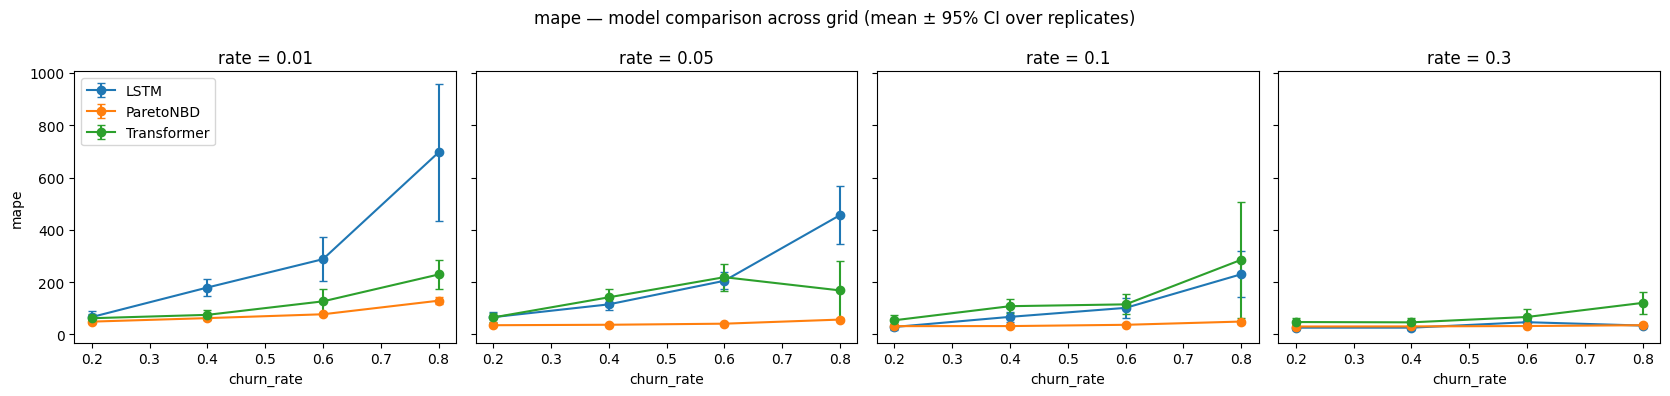

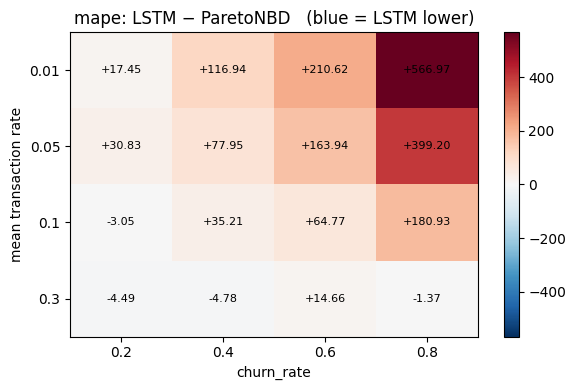

In [31]:
from panelclv.studies import (
    collect_grid_results, group_summary, compare_models_table,
plot_pattern, plot_diff_grid,
)

# study_dir = "/home/virthian/Desktop/Thesis/panelclv/Studies/pnbd_study_3x4x10_20260715-202011"
# study_dir from generation; train_base defaults to Studies/<study_dir name>
results = collect_grid_results(study_dir)          # long: model × dataset, tagged by grid cell
summary = group_summary(results, ci=0.95)          # mean + 95% CI per (model, rate, churn) group

compare_models_table(summary, "mape")              # per-group side-by-side (swap metric as needed)

for metric in ("rmse", "bias_percent", "mape"):
    plot_pattern(summary, metric)                  # patterns across datasets, per model, with CI
plot_diff_grid(results, "mape")

In [32]:
from panelclv.studies import seasonality_grid

tbl = seasonality_grid(study_dir)                 # train_base defaults to Studies/<study_dir name>
# or: seasonality_grid(study_dir, train_base="Studies/...")

In [33]:
tbl

model                                 LSTM  ParetoNBD  Transformer
mean_transaction_rate churn_rate                                  
0.01                  0.2         0.409821  -0.014927     0.261355
                      0.4         0.064309  -0.020223     0.057068
                      0.6        -0.044925  -0.030439     0.042544
                      0.8        -0.099274  -0.048707    -0.041537
0.05                  0.2         0.763881   0.010295     0.386927
                      0.4         0.632714  -0.006908     0.338748
                      0.6         0.126951  -0.025987     0.344689
                      0.8         0.007386  -0.042885     0.102164
0.10                  0.2         0.850617   0.014412     0.612391
                      0.4         0.804433  -0.004498     0.703417
                      0.6         0.775075  -0.022786     0.446123
                      0.8         0.547588  -0.040287     0.445288
0.30                  0.2         0.894369   0.016174     0.676211
                      0.4         0.903516  -0.003824     0.750369
                      0.6         0.877631  -0.020502     0.668729
                      0.8         0.802932  -0.035782     0.428984

In [38]:
from panelclv.studies import alive_volume_ratio_grid
tbl_alive = alive_volume_ratio_grid(study_dir)

In [39]:
tbl_alive
#Reading it: 
# 	> 1 = under-serves live customers (predicts too few);
#  < 1 = over-serves; = 1 = exactly right.

model                                 LSTM  ParetoNBD  Transformer
mean_transaction_rate churn_rate                                  
0.01                  0.2         1.046454   0.867763     0.854900
                      0.4         1.359069   0.740131     0.587671
                      0.6         1.268189   0.530571     0.610857
                      0.8         1.304616   0.323595     0.460914
0.05                  0.2         1.143579   0.872736     1.061313
                      0.4         0.944448   0.740661     1.048805
                      0.6         0.783667   0.628000     0.842653
                      0.8         0.632808   0.543139     0.317500
0.10                  0.2         0.848038   0.866760     0.959491
                      0.4         0.815996   0.752537     0.903810
                      0.6         0.677931   0.687673     0.673201
                      0.8         0.505964   0.615288     0.572233
0.30                  0.2         0.926493   0.888748     0.978355
                      0.4         0.821644   0.797984     0.783386
                      0.6         0.725983   0.749448     0.701391
                      0.8         0.457946   0.682729     0.585649

In [36]:
from panelclv.studies import dead_volume_leakage_grid
L = dead_volume_leakage_grid(study_dir)     # (rate × churn) × model, L_D = P_D / O_A
#It's a true customer-week classification (t < τ_i alive, else dead), so the post-death tail of customers who churn mid-holdout is counted, and O_A is the total oracle (dead-week oracle is zero by construction).

In [37]:
L

model                                 LSTM  ParetoNBD  Transformer
mean_transaction_rate churn_rate                                  
0.01                  0.2         0.418249   0.282877     0.337725
                      0.4         1.407559   0.511321     0.610438
                      0.6         2.646912   0.535302     1.274101
                      0.8         6.563426   0.491180     2.269925
0.05                  0.2         0.510654   0.208812     0.529593
                      0.4         1.215291   0.345223     1.380659
                      0.6         2.287460   0.389167     2.351692
                      0.8         4.765310   0.460263     2.151601
0.10                  0.2         0.340725   0.172189     0.494545
                      0.4         0.854411   0.249599     1.176135
                      0.6         1.312020   0.327460     1.409301
                      0.8         2.603809   0.392986     2.919244
0.30                  0.2         0.262102   0.116218     0.383372
                      0.4         0.363253   0.190426     0.604239
                      0.6         0.537178   0.261494     0.905987
                      0.8         0.358007   0.305303     1.579339